
# **Titanic Dataset — Exploratory Data Analysis**


---





>The sinking of the Titanic is one of the most discussed and tragic events of the early 1910s. This notebook analyses and predicts the survival of the passengers of the Titanic. The original dataset was taken from Kaggle and can be downloaded [here](https://www.kaggle.com/competitions/titanic/data) — place it in the same directory before running.






# LOADING AND CHECKING DATA

We begin the analysis by loading the data and importing the required libraries from Python. The libraries used in this notebook are: NumPy, Pandas, Matplotlib, and Seaborn.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (2).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
my_data = pd.read_csv("train.csv", index_col="PassengerId")

We have loaded the data from the **train.csv** file into the variable **my_data**. Before we proceed further, let's have a look at the first few rows of the table.


In [4]:
my_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# VARIABLE DESCRIPTION

The table above shows us that we have 11 columns, excluding PassengerID. Run the code block below to see the names of all these columns.

In [5]:
my_data.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Each column of our dataset, has a certain value or a characteristic of the passengers data that we have. The description of each of the columns are as follows:


1.   Survived: A 0 in the survived column indicates that the passenger did not survive while 1 indicates that the passenger survived. This is our target variable throughout our analysis.
2.   Pclass: The pclass column indicates the class in which the passenger was travelling in. (1=First Class(highest), 2=Second Class(middle) and 3=Third Class(lowest))
3. Name: This tells us the name of the passenger.
1. Sex: This tells us the gender of the person.
2. Age: This gives us the age of the passenger.
1. SibSp: The SibSp column gives us the number of siblings or spouses of the passenger aboard the Titanic.
2. Parch: Parch gives us the number of parents or children of the passenger aboard the Titanic.
1. Ticket: This tells us the ticket number of the passenger.
2. Fare: Fare indicates the amount the passenger had paid in order to travel in the Titanic.
1. Cabin: Cabin indicates the the cabin number of the passenger.
2. Embarked: Embarked gives us the port where the passenger had boarded the Titanic.











Now let us look at some statistical summary we can obtain from the data.




In [6]:
my_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


From the data above, we can say that we have data for a total of 891 passengers, with an average passenger age of around 30, although some age data is missing.

In [7]:
my_data.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


The results from the code blocks above tell us that we have a total of 891 passengers, of whom the age of 177 (19.86%), the cabin details of 687 (77.1%), and the embarkation port of 2 (0.2%) are unknown. Since 77% of cabin data is missing, we cannot draw any conclusions from that field. The age field needs to be filled in before use, while the embarkation field can be used as-is given its negligible missing rate

We fill in the missing values in the Age column with the median age.
We use the median instead of the mean because the mean is heavily influenced
by outliers, making it less representative of the typical passenger's age.

In [8]:
my_data['Age']=my_data['Age'].fillna(my_data['Age'].median())

# UNIVARIATE VARIABLE ANALYSIS

> In univariate variable analysis, we independently analyse a variable without looking at or analysing its relationship with other variables.





We first begin with the analysis of the Survived column, which will give us an idea of the number of people who survived the Titanic disaster.

In [9]:
my_data['Survived'].value_counts()

,count
Survived,
0,549
1,342


/tmp/ipykernel_38503/1490785646.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=my_data, x=my_data.Survived, palette=["red","green"])


<Axes: xlabel='Survived', ylabel='count'>

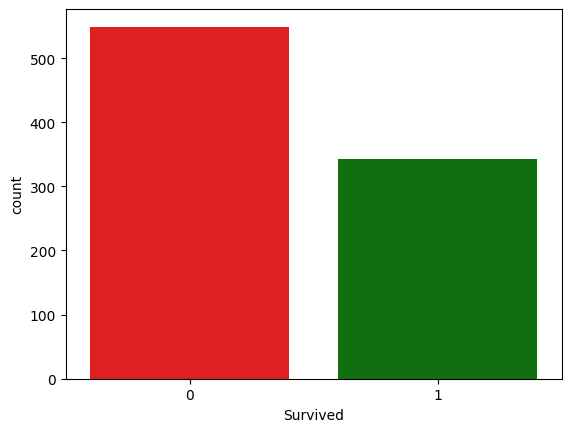

In [10]:
sns.countplot(data=my_data, x=my_data.Survived, palette=["red","green"])

The data and the plot above show us that nearly 61.6% of the people on the Titanic died while the remaining 38.4% survived. This is a classic example of class imbalance — a concept in Machine Learning that occurs when the data distribution is non-uniform and varies drastically. Now let us proceed further and check the passengers aboard the Titanic based on age.

<Axes: xlabel='Age', ylabel='Count'>

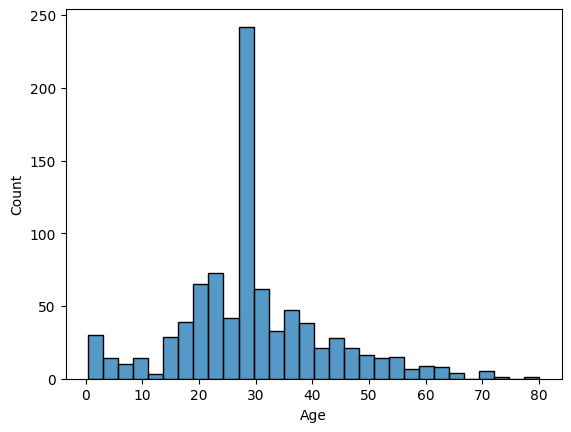

In [11]:
sns.histplot(my_data.Age)

From the histogram above, we can observe that the distribution peaks between the ages of 20 and 30, indicating that the majority of passengers aboard the Titanic were young adults. The number of passengers aged between 60 and 80 was significantly lower, suggesting that the Titanic carried a predominantly young crowd. Another interesting observation is that among younger passengers, children under the age of 5 outnumbered teenagers.

Moving on, let's look at the number of passengers based on their gender.

In [12]:
my_data['Sex'].value_counts()

,count
Sex,
male,577
female,314


<Axes: xlabel='Sex', ylabel='count'>

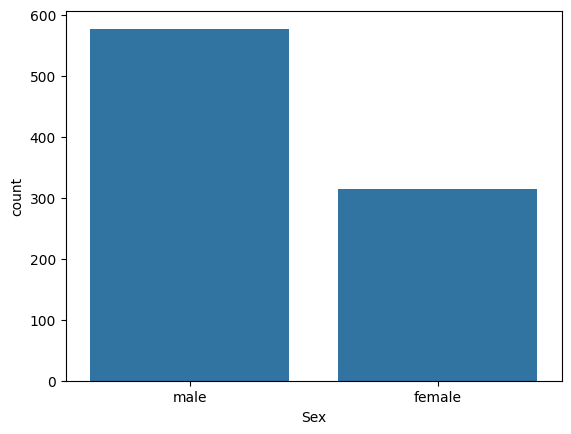

In [13]:
sns.countplot(data=my_data, x=my_data.Sex)

The graph and the counts tell us that nearly 64.8% of the passengers aboard were male while the remaining 35.2% were female.

# BIVARIATE VARIABLE ANALYSIS

> Bivariate variable analysis helps us identify the relationship between two different variables. In our EDA, we will be doing all the bivariate analysis with respect to the Survived variable, as our major goal is to understand what factors affected the survival of a passenger.



We begin with the bivariate analysis of Sex and Survived, which will tell us if there was any relationship between the chance of survival and the gender of the passenger.

In [14]:
my_data.groupby('Sex')['Survived'].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

<Axes: xlabel='Sex', ylabel='count'>

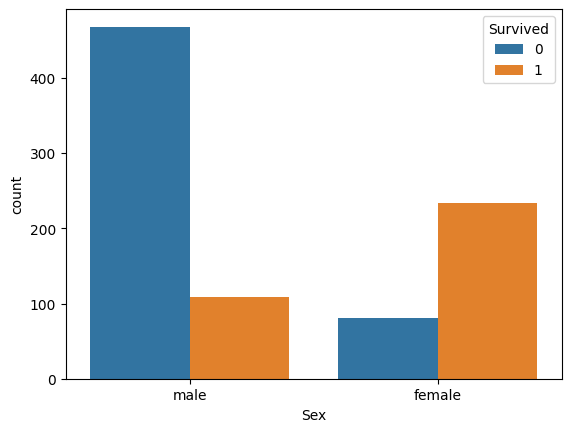

In [15]:
sns.countplot(x=my_data.Sex, hue=my_data.Survived)

The graph and the data above show us that only 18.9% of male passengers survived while 74.2% of female passengers survived, indicating that a greater number of women were rescued compared to men. Next, we proceed to do the bivariate analysis of Pclass and Survived.

In [16]:
my_data.groupby('Pclass')['Survived'].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

<Axes: xlabel='Pclass', ylabel='count'>

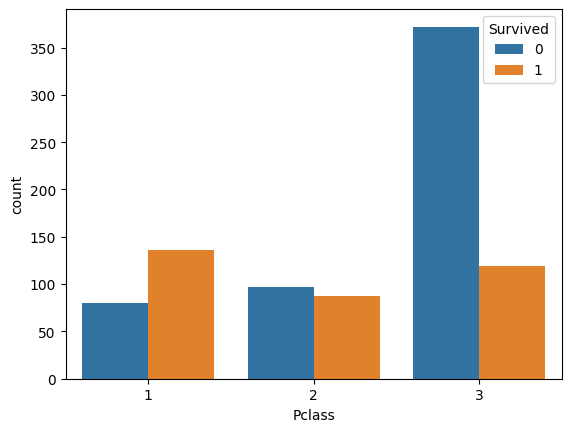

In [17]:
sns.countplot(x=my_data.Pclass, hue=my_data.Survived)

The data tells us that around 63% of passengers survived from 1st class, 47.2% survived from 2nd class, and only 24.2% from 3rd class survived, indicating that class played a very important role in determining the survival rate. Next, we proceed to do the bivariate analysis of Age and Survived.

<Axes: xlabel='Age', ylabel='Count'>

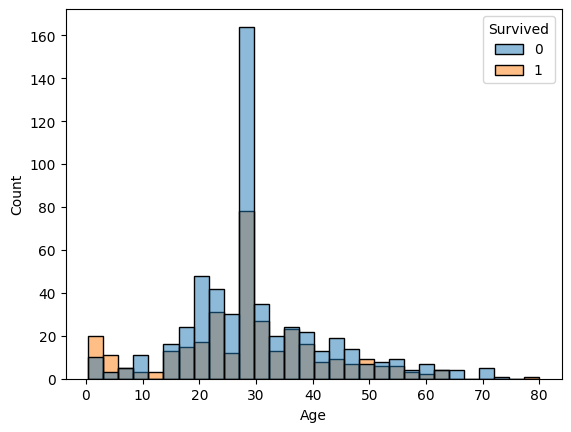

In [18]:
sns.histplot(x=my_data.Age, hue=my_data.Survived)

The comparison between age and survival shows us that most children below the age of 10 survived, while the survival rate was very low for adults and seniors, indicating that children were prioritised for rescue. Next, we proceed to do the bivariate analysis of Fare and Survived.

<Axes: xlabel='Fare', ylabel='Count'>

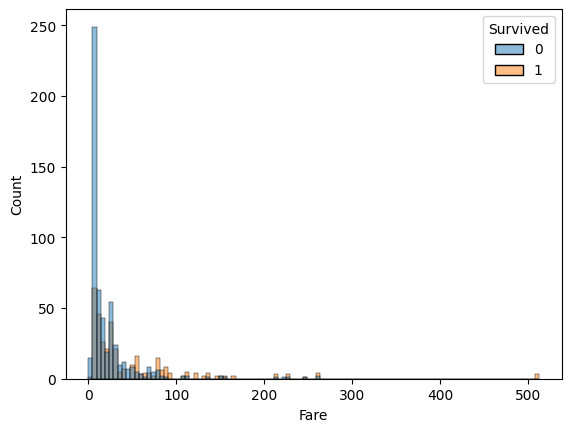

In [19]:
sns.histplot(x=my_data.Fare, hue=my_data.Survived)

The graph above shows us that the higher the fare paid by a passenger, the higher the survival rate. This was mainly due to the fact that passengers who paid more were in a higher class, and those in higher classes had better access to lifeboats.

# CORREALATION ANALYSIS

Let us now examine the correlation between the numerical variables in our dataset.

In [20]:
my_data.corr(numeric_only=True)

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


<Axes: >

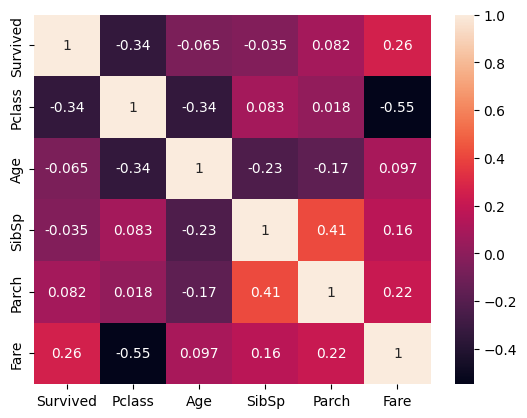

In [21]:
sns.heatmap(my_data.corr(numeric_only=True), annot= True)

From the heatmap above, we can conclude that:
*   As Pclass increases, the survival rate decreases.
*   Age and survival rate do not have a strong correlation.

*   Fare shows a positive relationship with survival rate — as fare increases, survival rate increases.
*  SibSp and Parch do not have a strong relationship with survival rate.









# FEATURE ENGINEERING

> In feature engineering, what we do is create new variables (columns) from the existing variables in order to find more relationships within the data and improve the accuracy of our analysis



We now create a new column, FamilySize, by adding up the number of siblings/spouses a person has aboard (SibSp), the number of parents/children aboard (Parch), and 1 (for the person themselves), so that we can analyse whether the number of family members aboard had an effect on a passenger's survival.

In [22]:
my_data['FamilySize'] = my_data['SibSp'] + my_data['Parch'] + 1

In [23]:
my_data.groupby('FamilySize')['Survived'].value_counts()

FamilySize  Survived
1           0           374
            1           163
2           1            89
            0            72
3           1            59
            0            43
4           1            21
            0             8
5           0            12
            1             3
6           0            19
            1             3
7           0             8
            1             4
8           0             6
11          0             7
Name: count, dtype: int64

<Axes: xlabel='FamilySize', ylabel='Count'>

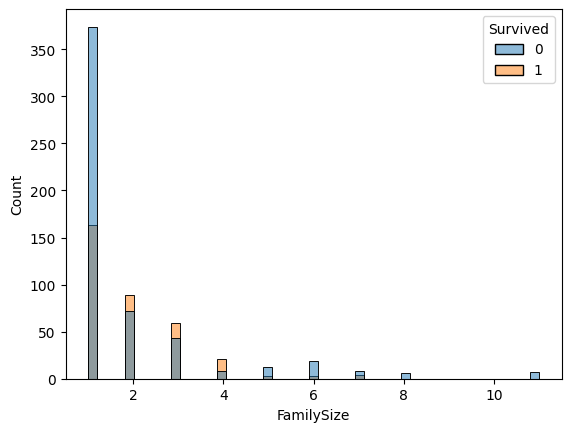

In [24]:
sns.histplot(x=my_data.FamilySize, hue=my_data.Survived)

The analysis above shows us that solo travellers had a low survival rate nearly 30%, small families of 2-4 had the best survival rate, and large families of 5+ had poor survival again.

We now create a new column named Title, which helps us get the count of people with each title and analyse further.

In [25]:
my_data['Title'] = my_data['Name'].str.extract(r' ([A-Za-z]+)\.')
my_data['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [26]:
my_data.groupby('Title')['Survived'].value_counts()

Title     Survived
Capt      0             1
Col       0             1
          1             1
Countess  1             1
Don       0             1
Dr        0             4
          1             3
Jonkheer  0             1
Lady      1             1
Major     0             1
          1             1
Master    1            23
          0            17
Miss      1           127
          0            55
Mlle      1             2
Mme       1             1
Mr        0           436
          1            81
Mrs       1            99
          0            26
Ms        1             1
Rev       0             6
Sir       1             1
Name: count, dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, 'Mr'),
  Text(1, 0, 'Mrs'),
  Text(2, 0, 'Miss'),
  Text(3, 0, 'Master'),
  Text(4, 0, 'Don'),
  Text(5, 0, 'Rev'),
  Text(6, 0, 'Dr'),
  Text(7, 0, 'Mme'),
  Text(8, 0, 'Ms'),
  Text(9, 0, 'Major'),
  Text(10, 0, 'Lady'),
  Text(11, 0, 'Sir'),
  Text(12, 0, 'Mlle'),
  Text(13, 0, 'Col'),
  Text(14, 0, 'Capt'),
  Text(15, 0, 'Countess'),
  Text(16, 0, 'Jonkheer')])

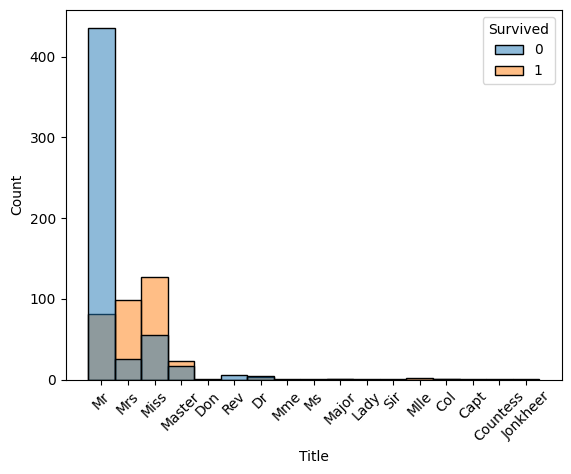

In [27]:
sns.histplot(x=my_data.Title, hue = my_data.Survived)
plt.xticks(rotation=45)

In the graph above, the titles indicate the following:
*   Mr — adult male
*   Mrs — married female
*   Miss — unmarried female
*   Master — young male

The title is a more effective method of analysis compared to analysing sex and age separately. The graph shows us that the survival rate of passengers with the titles Mrs and Miss was higher compared to male passengers; however, among male passengers, those with the title Master had a higher survival rate.




# SUMMARY

Summarising our entire Titanic dataset EDA, the dataset contains the details of 891 passengers who travelled on the Titanic, of whom only 342 survived, indicating a loss of around 61.6% of the travellers.
Based on the analysis, we can conclude that gender, age, and fare played a very important role in determining the survival of a passenger. While the survival rate of women was approximately 74%, the survival rate among men was as low as 19%. Children under the age of 10 had a higher survival rate, indicating that the "women and children first" approach had a significant impact on survival.
Another major factor was the fare — the more a passenger paid, the higher their chance of survival, since a higher fare meant a higher passenger class, and a higher passenger class indicated easier and more feasible access to the lifeboats.